In [1]:
import nltk

In [2]:
from nltk.corpus import stopwords
nltk.download('stopwords')
sw=stopwords.words('english')
# sw=stopwords.words('chinese')

sw
#print(len(sw))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [3]:
s='the sun rise in the east'

from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
tokens=word_tokenize(s)

tokens

# a=s.split()
# a

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['the', 'sun', 'rise', 'in', 'the', 'east']

In [4]:
from nltk.util import ngrams

ng=ngrams(sequence=tokens,n=2)

list(ng)

[('the', 'sun'),
 ('sun', 'rise'),
 ('rise', 'in'),
 ('in', 'the'),
 ('the', 'east')]

In [5]:
s='this is a sample sentence for stopword removal'

# wap to find the words which has length greater than 4
l=[]
tokens=word_tokenize(s)
for i in tokens:
  if len(i)>4:
    l.append(i)
print(l)

['sample', 'sentence', 'stopword', 'removal']


In [9]:
# wap to remove stopwords from a given sentence

s='this is a sample sentence for stopword removal'
a=s.split()
l=[i for i in a if i.lower() not in sw]
l

['sample', 'sentence', 'stopword', 'removal']

In [10]:
# stemming :porterstemmer english, snowball stemmer: other language

In [11]:
from nltk.stem import PorterStemmer

ps=PorterStemmer()
ps.stem('eating')

'eat'

In [12]:
l=['eating','jumping','running']
l1=[ps.stem(i) for i in l]
l1

['eat', 'jump', 'run']

In [13]:
from nltk.stem import SnowballStemmer
sn=SnowballStemmer('english')
sn.stem('eating')

'eat'

In [14]:
l=['flying','crying','jumped']
l1=[sn.stem(i) for i in l]
l1

['fli', 'cri', 'jump']

In [18]:
# lemmatization

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
wn=WordNetLemmatizer()

wn.lemmatize('caring',pos='v')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


'care'

In [25]:
l=['dreaming','running','jumped','ate']

l1=[wn.lemmatize(i,pos='v') for i in l]
l1

['dream', 'run', 'jump', 'eat']

In [32]:
s=['earth is the third planet from the sun','jupiter is the largest planet']

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()

y=tfidf.fit_transform(s)

print(y)

print(tfidf.get_feature_names_out())
v=tfidf.get_feature_names_out()
print(y.toarray())

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12 stored elements and shape (2, 9)>
  Coords	Values
  (0, 0)	0.37695708675831013
  (0, 2)	0.2682080718928097
  (0, 7)	0.5364161437856194
  (0, 8)	0.37695708675831013
  (0, 5)	0.2682080718928097
  (0, 1)	0.37695708675831013
  (0, 6)	0.37695708675831013
  (1, 2)	0.3793034928087496
  (1, 7)	0.3793034928087496
  (1, 5)	0.3793034928087496
  (1, 3)	0.5330978245262535
  (1, 4)	0.5330978245262535
['earth' 'from' 'is' 'jupiter' 'largest' 'planet' 'sun' 'the' 'third']
[[0.37695709 0.37695709 0.26820807 0.         0.         0.26820807
  0.37695709 0.53641614 0.37695709]
 [0.         0.         0.37930349 0.53309782 0.53309782 0.37930349
  0.         0.37930349 0.        ]]


In [35]:
import pandas as pd

df=pd.DataFrame(y.toarray(),columns=v)

df

,earth,from,is,jupiter,largest,planet,sun,the,third
0,0.376957,0.376957,0.268208,0.000000,0.000000,0.268208,0.376957,0.536416,0.376957
1,0.000000,0.000000,0.379303,0.533098,0.533098,0.379303,0.000000,0.379303,0.000000


In [36]:
df=pd.read_csv('/content/Tweets.csv')
df

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive


In [37]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


<Axes: xlabel='sentiment', ylabel='count'>

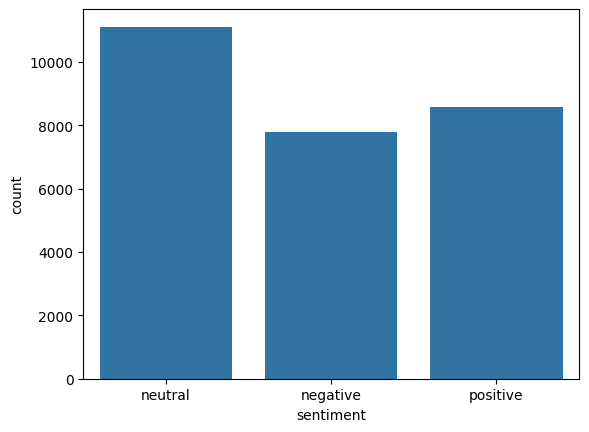

In [39]:
import seaborn as sns

sns.countplot(x=df['sentiment'])

In [41]:
df.isna().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [42]:
df.dropna(inplace=True)

In [45]:
df.isnull().sum()

,0
textID,0
text,0
selected_text,0
sentiment,0


In [46]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [48]:
df.drop(['textID','selected_text'],axis=1,inplace=True)

In [49]:
df.head()


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative
